In [7]:
# notebooks/visual_features.py
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [18]:
Z.shape

(331, 2)

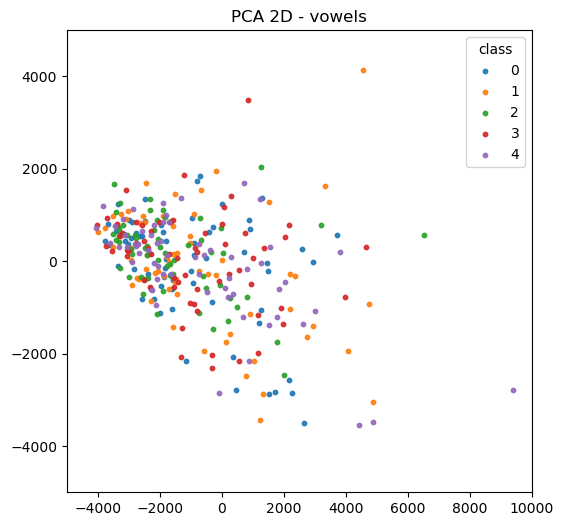

In [23]:
feat_dir = Path("../features/preproc_dwt_L5_db4/per_subject")
subj = "S01_EEG"
X3 = np.load(feat_dir / f"{subj}_features.npy")
labels = np.load(feat_dir / f"{subj}_labels.npy")
task = np.load(feat_dir / f"{subj}_task.npy")

mask = (task==0)  # vowels
X = X3[mask].reshape(mask.sum(), -1)
y = labels[mask][:,1].astype(int) - 1

# PCA
pca = PCA(2)
Z = pca.fit_transform(X)
plt.figure(figsize=(6,6))
for c in np.unique(y):
    idx = y==c
    plt.scatter(Z[idx,0], Z[idx,1], label=str(c), s=10, alpha=0.9)
#plt.xscale("log")
#plt.yscale('log')
plt.xlim((-5000, 10000))
plt.ylim((-5000, 5000))
plt.legend(title="class")
plt.title("PCA 2D - vowels")
plt.show()

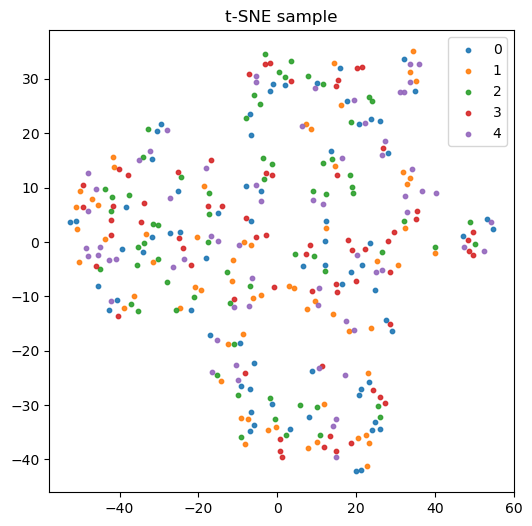

In [42]:
# t-SNE (puede tardar)
Zts = TSNE(n_components=2, perplexity = 10, early_exaggeration = 10, max_iter=1000, random_state = 42).fit_transform(X)  # sample if big
plt.figure(figsize=(6,6))
for c in np.unique(y):
    idx = y==c
    plt.scatter(Zts[idx, 0], Zts[idx, 1], label = str(c), s = 10, alpha = 0.9)
#plt.scatter(Zts[:,0], Zts[:,1], c=y[:1000], s=8, cmap='tab10')
plt.title("t-SNE sample")
plt.legend()
plt.show()